In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [ ]:
data = pd.read_csv("C:/Users/maysha/Downloads/archive(2)/Autism-Child-Data.csv")


# Display the first 5 Rows

In [3]:
data.head()


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,0,0,1,1,0,1,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,2,1,1,0,0,1,1,0,1,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,3,1,1,0,0,0,1,1,1,0,...,m,?,no,no,Jordan,yes,5,4-11 years,?,NO
3,4,0,1,0,0,1,1,0,0,0,...,f,?,yes,no,Jordan,no,4,4-11 years,?,NO
4,5,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [4]:
data.tail()

,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
287,288,1,1,1,1,1,1,1,1,1,...,f,White-European,yes,yes,United Kingdom,no,10,4-11 years,Parent,YES
288,289,1,0,0,0,1,0,1,0,0,...,f,White-European,yes,yes,Australia,no,4,4-11 years,Parent,NO
289,290,1,0,1,1,1,1,1,0,0,...,m,Latino,no,no,Brazil,no,7,4-11 years,Parent,YES
290,291,1,1,1,0,1,1,1,1,1,...,m,South Asian,no,no,India,no,9,4-11 years,Parent,YES
291,292,0,0,1,0,1,0,1,0,0,...,f,South Asian,no,no,India,no,3,4-11 years,Parent,NO


# Displaying null values

In [5]:
data.isna().sum()

id                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [6]:
data.columns


Index(['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

# Dropping the 'id' column because it is irreleavant to the dataset

In [7]:
data=data.drop("id",axis=1)

In [8]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


# There was '?' as null in the dataset, so we replace it with NA Values

In [9]:
data.replace('?', pd.NA, inplace=True)


In [10]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,<NA>,no,no,Jordan,yes,5,4-11 years,<NA>,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,<NA>,yes,no,Jordan,no,4,4-11 years,<NA>,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [11]:
data.isna().sum()

A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 4
gender              0
ethnicity          43
jundice             0
austim              0
contry_of_res       0
used_app_before     0
result              0
age_desc            0
relation           43
Class/ASD           0
dtype: int64

In [12]:
data.isna().sum().sum()

90

# Filling Null values in ethnicity, age, relation columns with 'Others', '4-11 years' and 'Health care professional' respectively

In [13]:
data.fillna({'ethnicity':'Others','age':'4-11 years','relation':'Health care professional'}, inplace=True)

In [14]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,Others,no,no,Jordan,yes,5,4-11 years,Health care professional,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,Others,yes,no,Jordan,no,4,4-11 years,Health care professional,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [15]:
data.isna().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [16]:
data.fillna(value='4-11 years', inplace=True)

In [17]:
data['age'] = data['age'].replace('4-11 years', pd.NA)

In [18]:
first_tuple = data.iloc[32]
print(first_tuple)

A1_Score                                  1
A2_Score                                  0
A3_Score                                  0
A4_Score                                  1
A5_Score                                  0
A6_Score                                  1
A7_Score                                  1
A8_Score                                  1
A9_Score                                  1
A10_Score                                 1
age                                    <NA>
gender                                    m
ethnicity                            Others
jundice                                  no
austim                                   no
contry_of_res                         Egypt
used_app_before                          no
result                                    7
age_desc                         4-11 years
relation           Health care professional
Class/ASD                               YES
Name: 32, dtype: object


# Replacing Null values in age with the previous values

In [19]:
data.fillna(method = 'pad', inplace= True)

In [20]:
first_tuple = data.iloc[32]
print(first_tuple)

A1_Score                                  1
A2_Score                                  0
A3_Score                                  0
A4_Score                                  1
A5_Score                                  0
A6_Score                                  1
A7_Score                                  1
A8_Score                                  1
A9_Score                                  1
A10_Score                                 1
age                                       6
gender                                    m
ethnicity                            Others
jundice                                  no
austim                                   no
contry_of_res                         Egypt
used_app_before                          no
result                                    7
age_desc                         4-11 years
relation           Health care professional
Class/ASD                               YES
Name: 32, dtype: object


In [21]:
data.isna().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

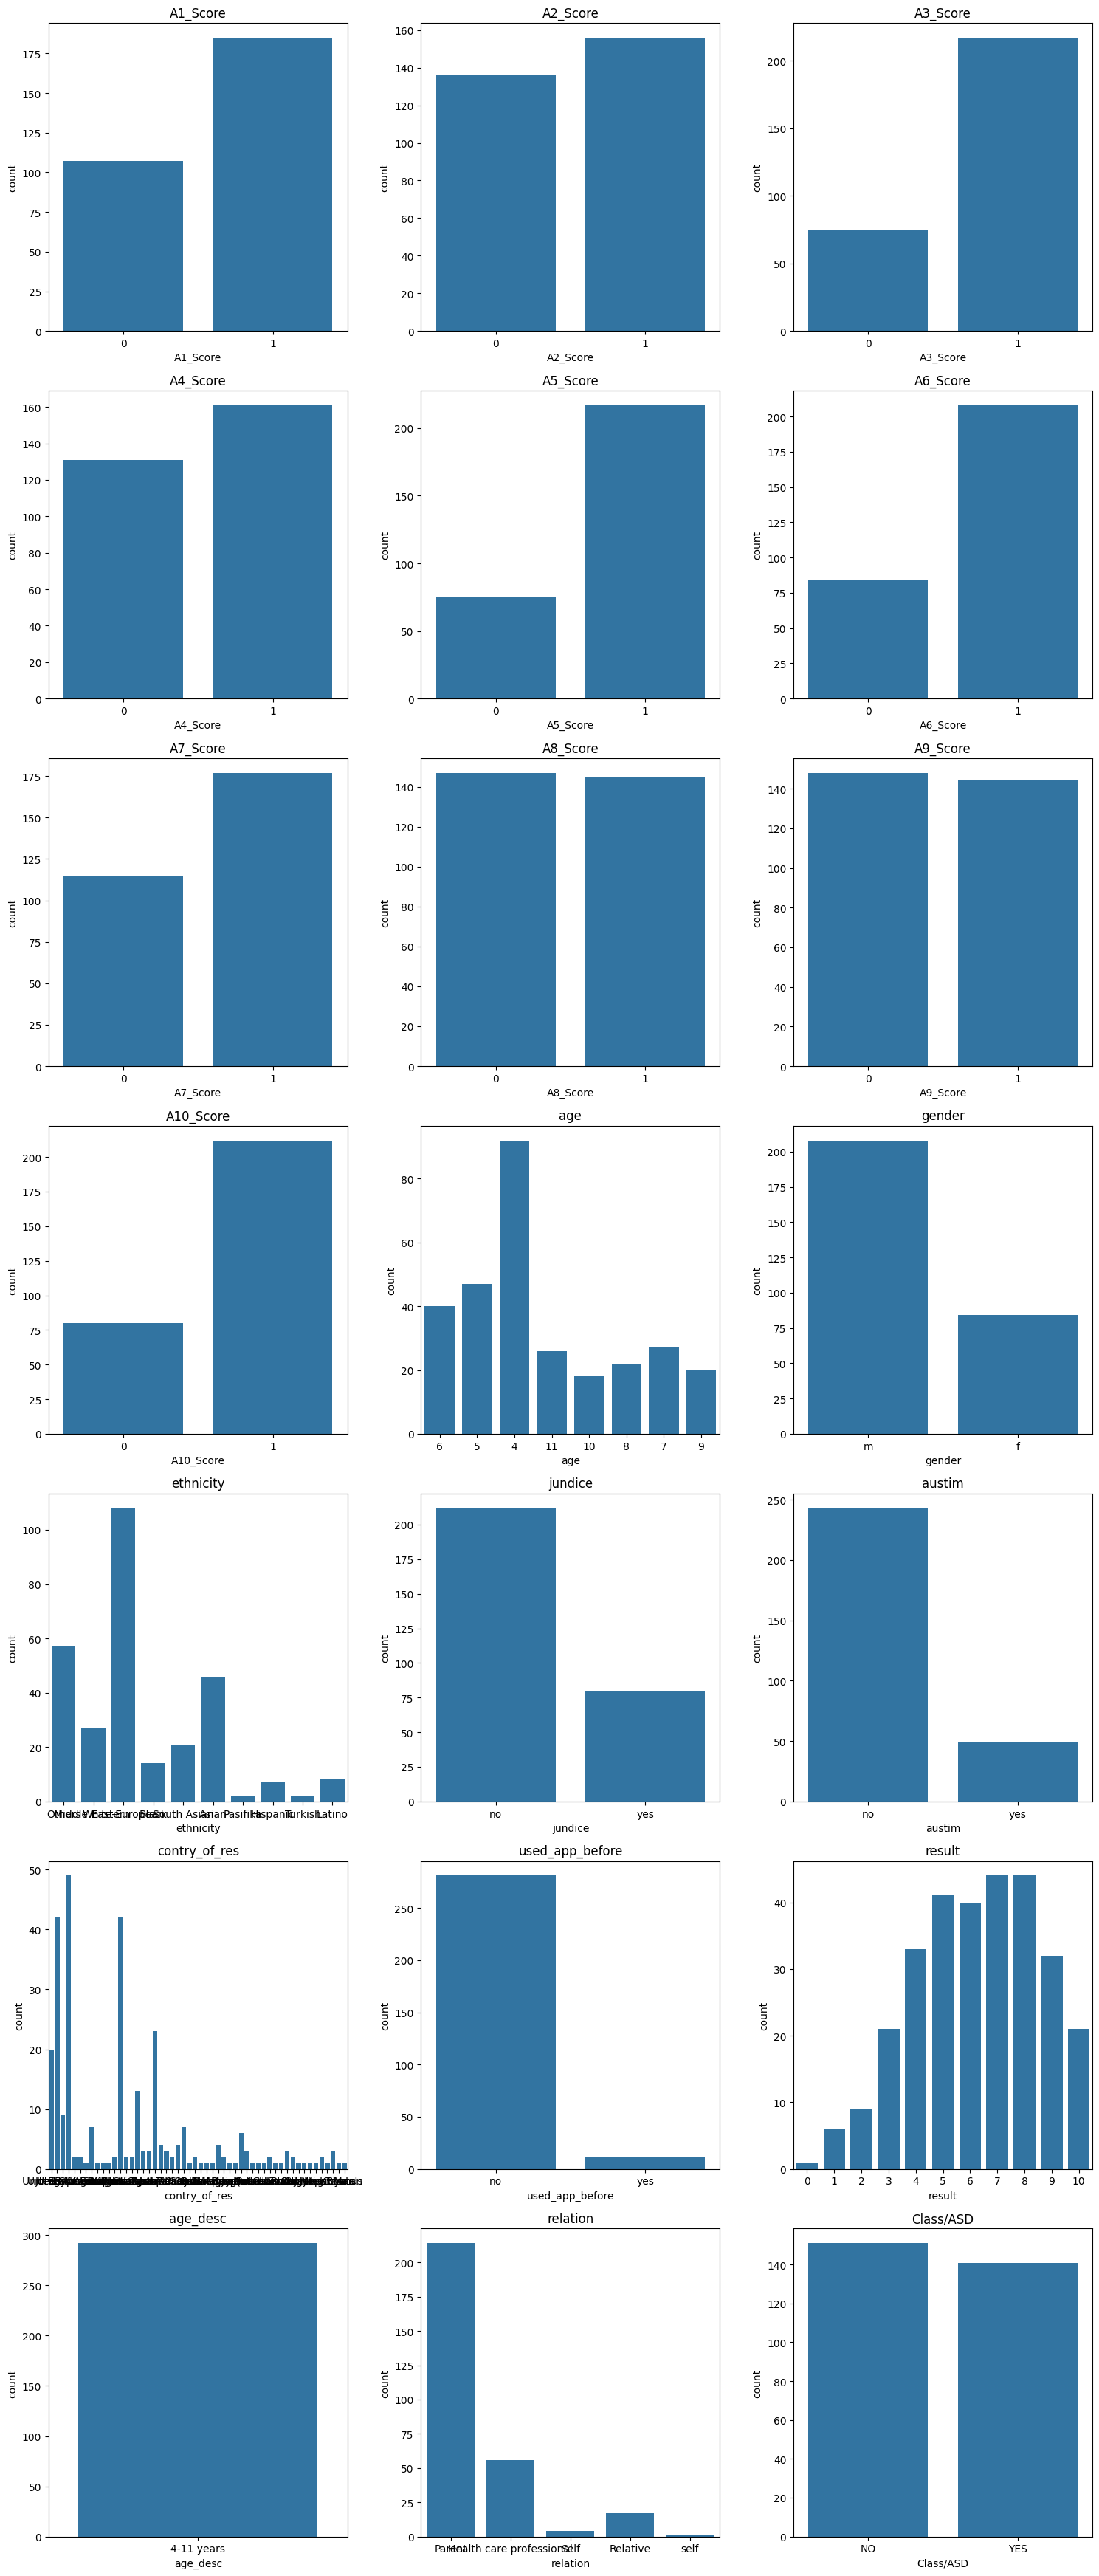

In [22]:
fig, axes = plt.subplots(7, 3, figsize=(15, 35)) 
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :21]): 
    sns.countplot(x=data[col], ax=axes[i])
    axes[i].set_title(col)
    if i >= 20: 
        break
plt.tight_layout()
plt.show()

In [23]:
  if col == "contry_of_res" or col == "ethnicity" or col == "relation":
        axes[i].tick_params(axis="x", labelrotation=90)

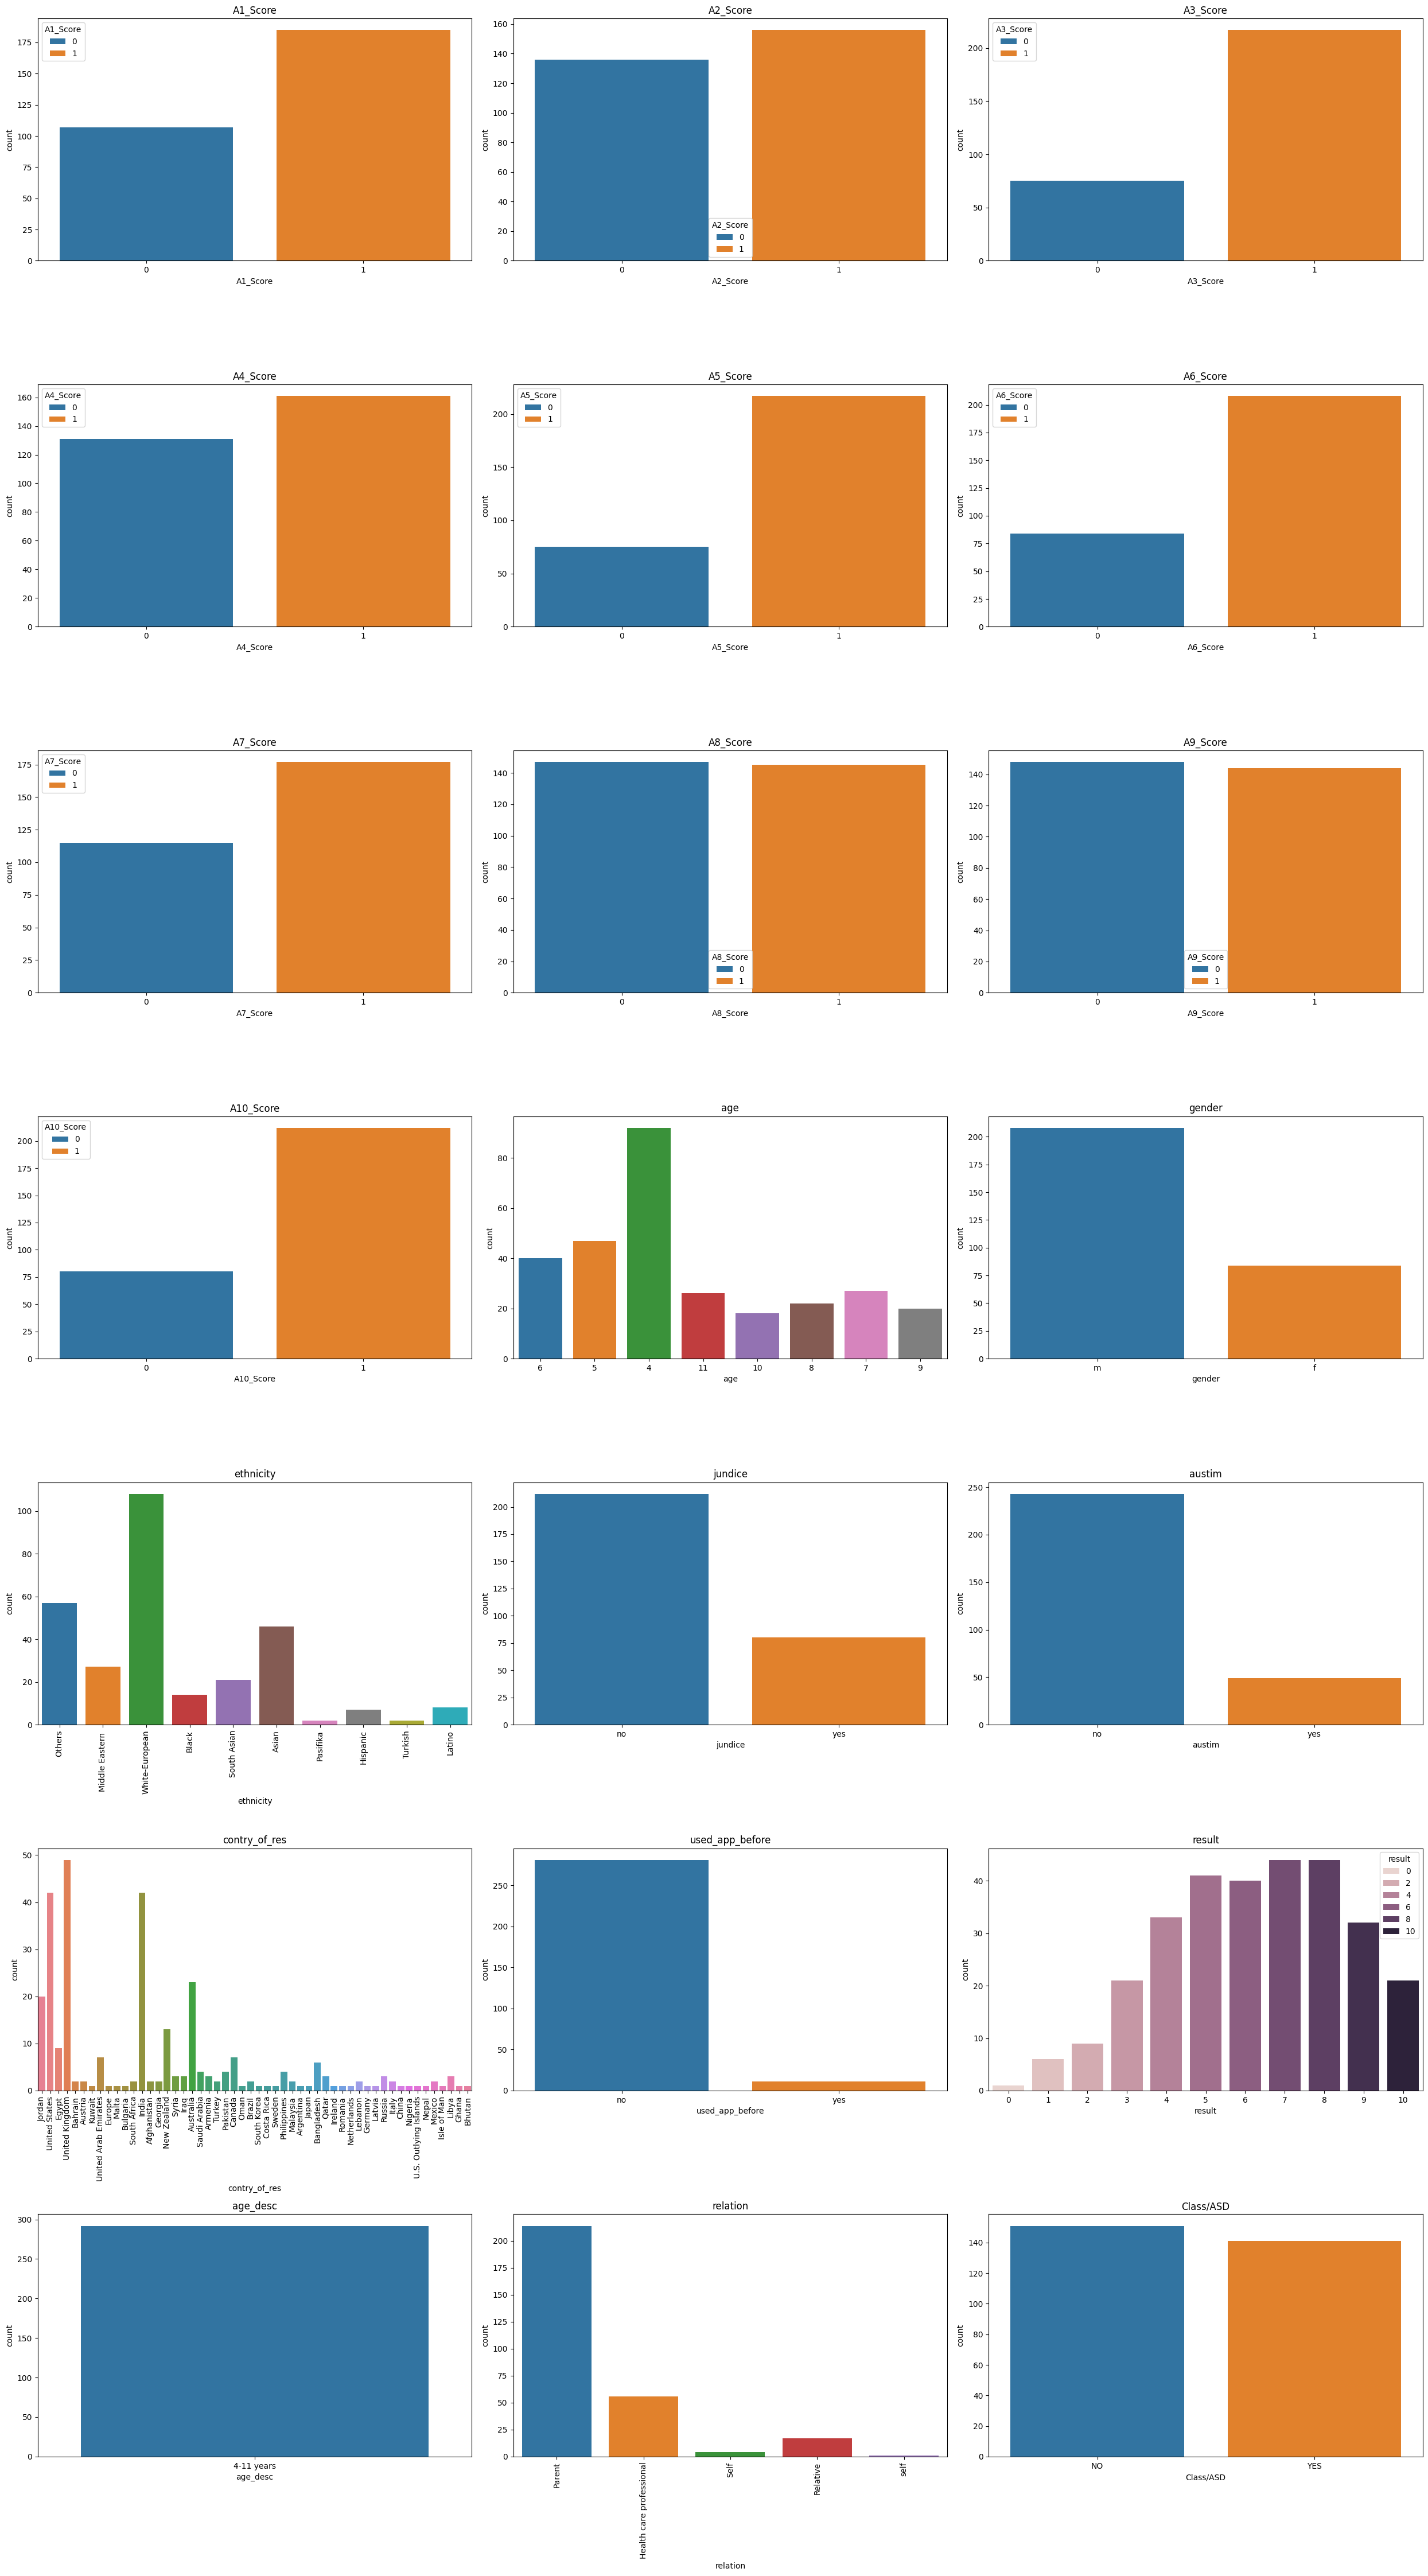

In [24]:

fig, axes = plt.subplots(7, 3, figsize=(25, 45))
axes = axes.ravel()

for i, col in enumerate(data.iloc[:, :21]): 
    sns.countplot(x=data[col], hue=data[col],ax=axes[i])
    axes[i].set_title(col)
    if col == "contry_of_res" or col == "ethnicity" or col == "relation":
        axes[i].tick_params(axis="x", labelrotation=90)
    if i >= 20: 
        break

plt.tight_layout()
plt.show()

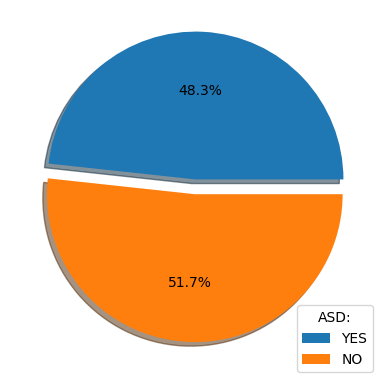

In [25]:
labels = ["YES", "NO"]
myexplode = [0.1, 0]
plt.pie(data.groupby('Class/ASD').size().reindex(labels),explode = myexplode, shadow = True,autopct='%1.1f%%')
plt.legend(title = "ASD:",labels = labels)
plt.show()

C:\Users\samiu\AppData\Local\Temp\ipykernel_14996\3837637230.py:6: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


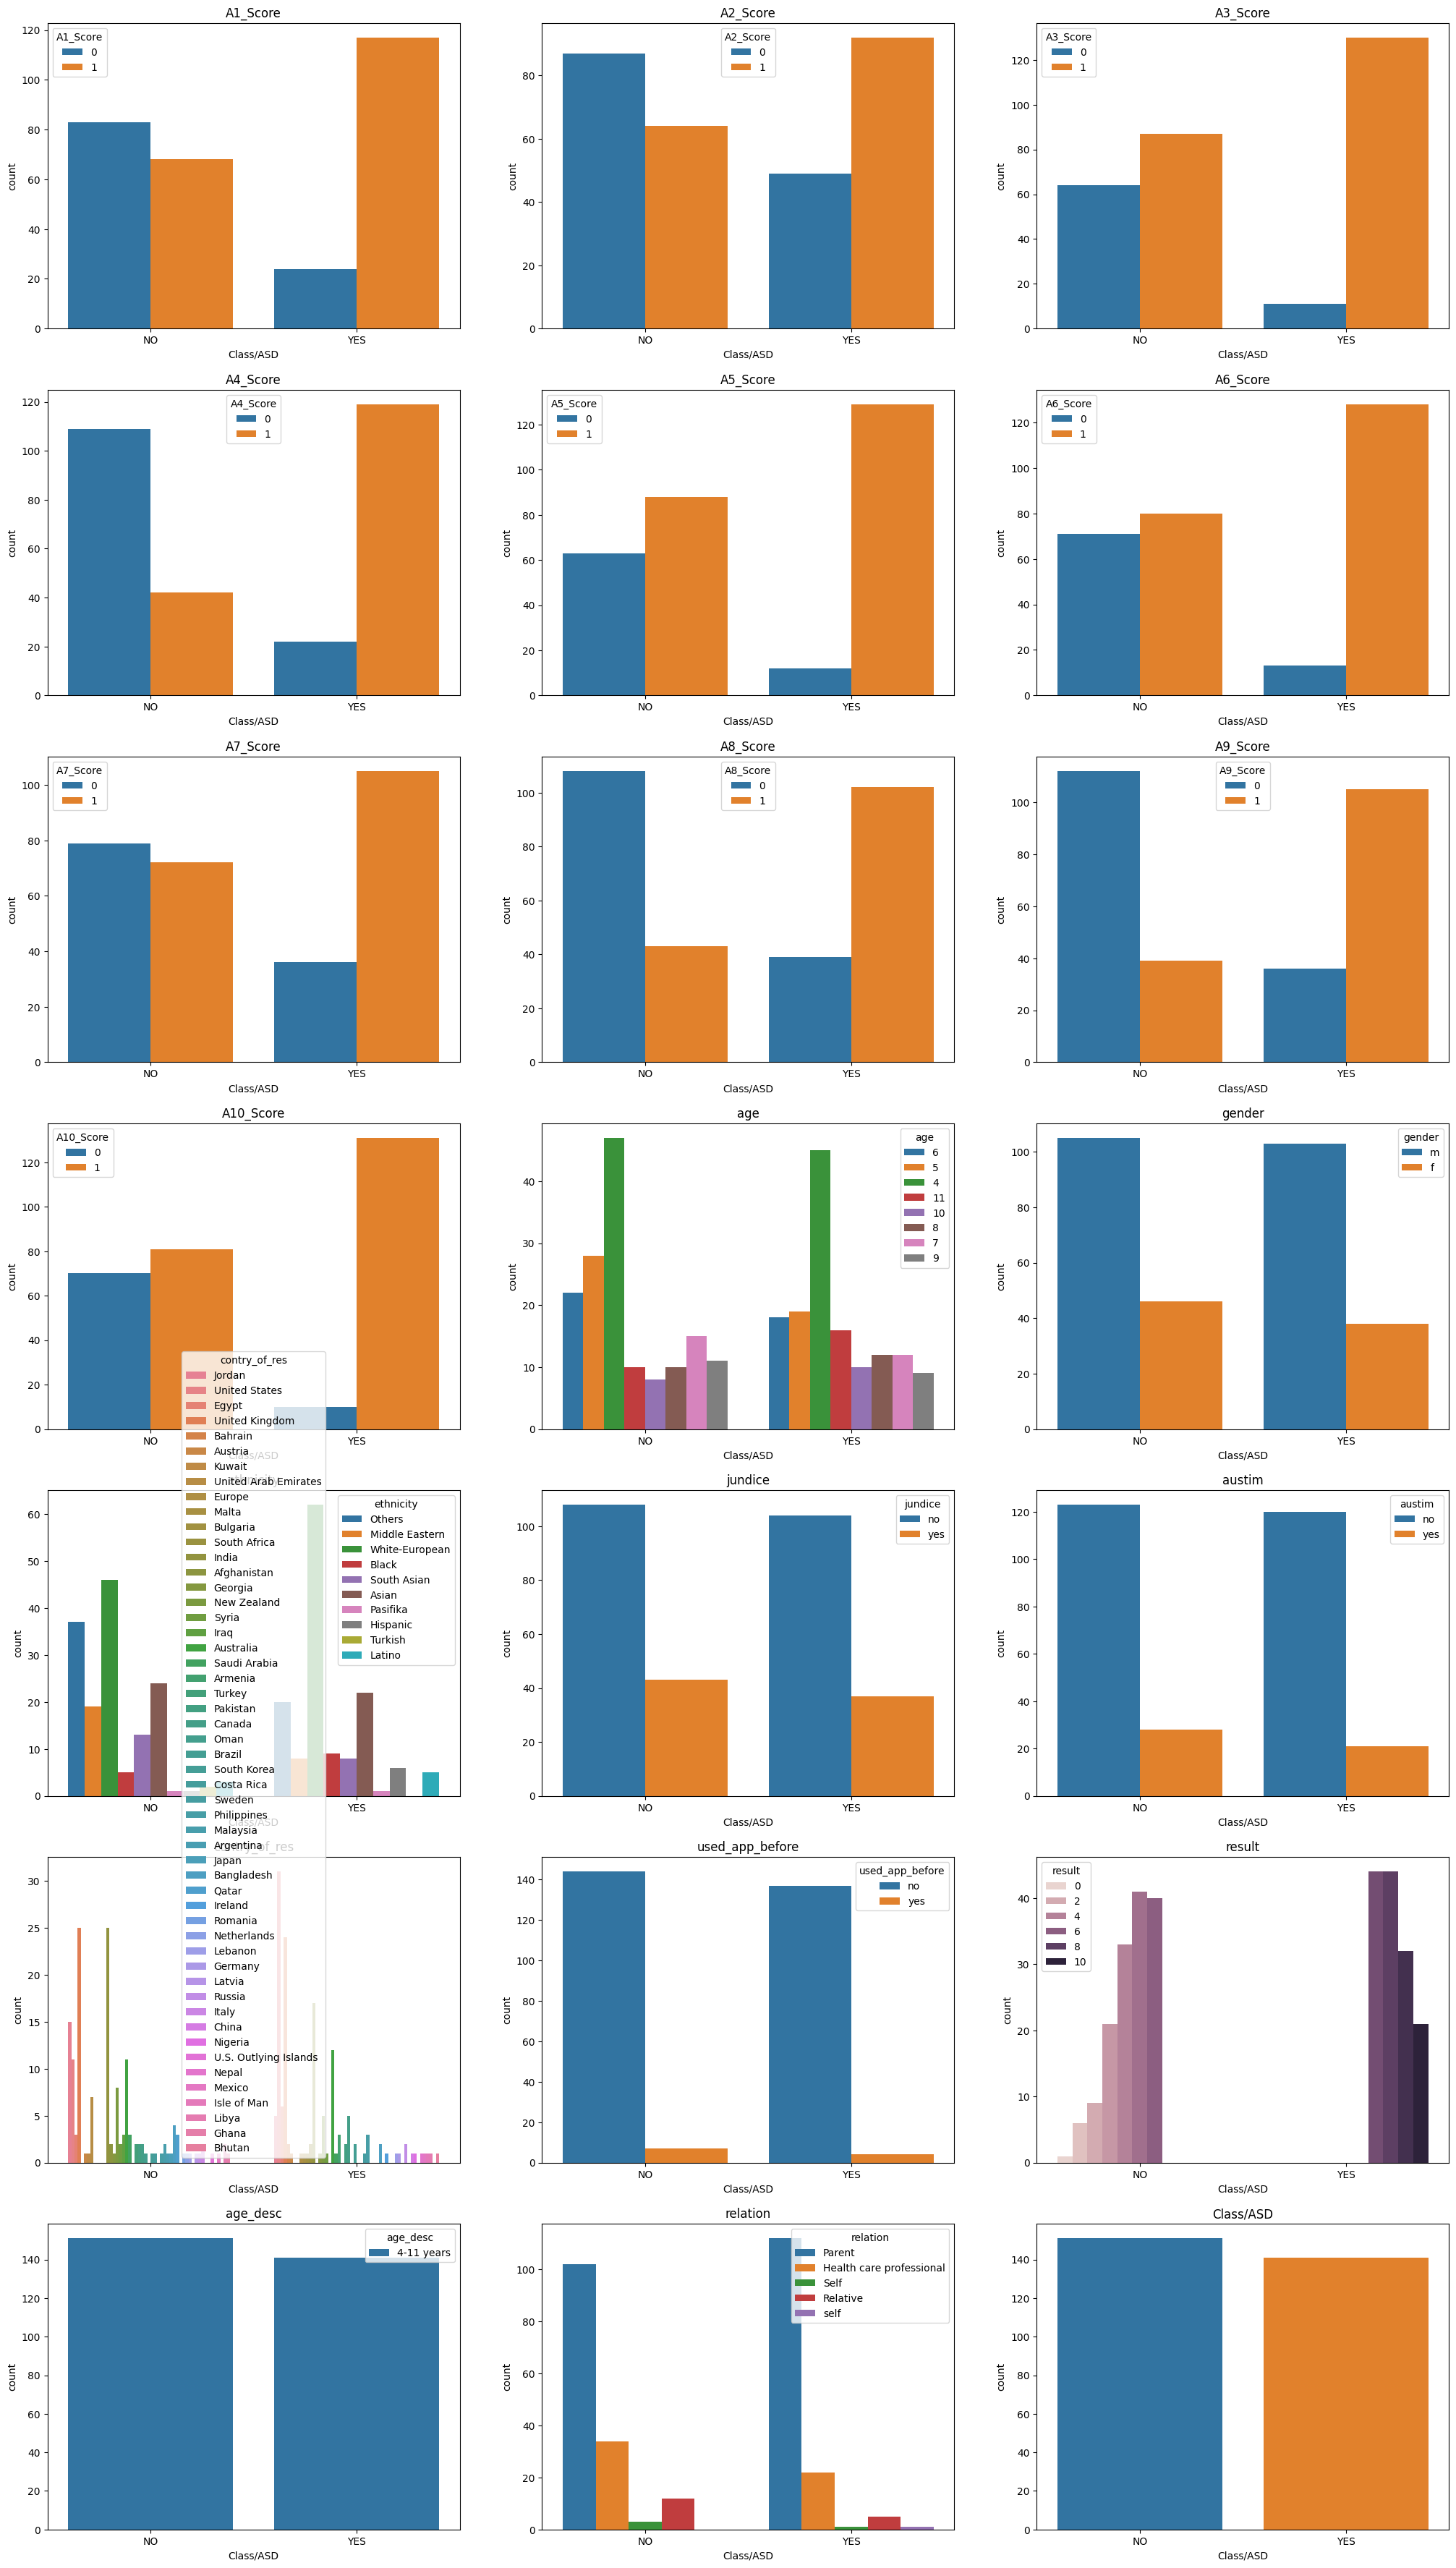

In [26]:
fig, axes = plt.subplots(7, 3, figsize=(25, 45))
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :]):
    sns.countplot(x=data["Class/ASD"], hue=data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [27]:
data.groupby('ethnicity').size()

ethnicity
Asian               46
Black               14
Hispanic             7
Latino               8
Middle Eastern      27
Others              57
Pasifika             2
South Asian         21
Turkish              2
White-European     108
dtype: int64

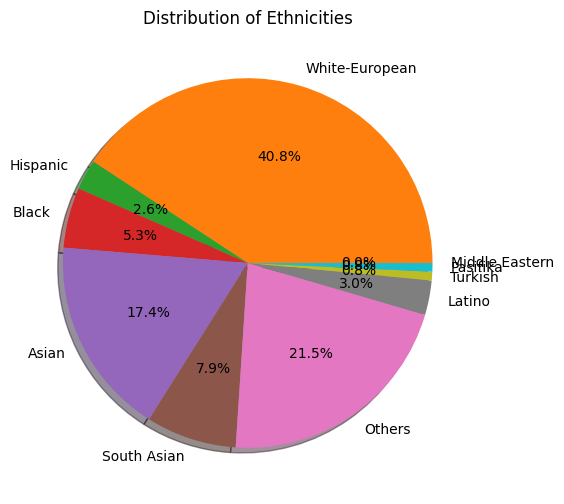

In [28]:
# Define the labels
labels = ['Middle Eastern', 'White-European', 'Hispanic', 'Black', 'Asian',
          'South Asian', 'Others', 'Latino', 'Turkish', 'Pasifika']

# Group the data by 'ethnicity' and count the occurrences, then reindex with the defined labels
grouped_data = data.groupby('ethnicity').size().reindex(labels)

# Check for NaN values and replace them with 0
grouped_data = grouped_data.fillna(0)

# Plot the pie chart
plt.figure(figsize=(10, 6))
plt.pie(grouped_data, labels=labels, autopct='%1.1f%%', shadow=True)
plt.title('Distribution of Ethnicities')
plt.show()

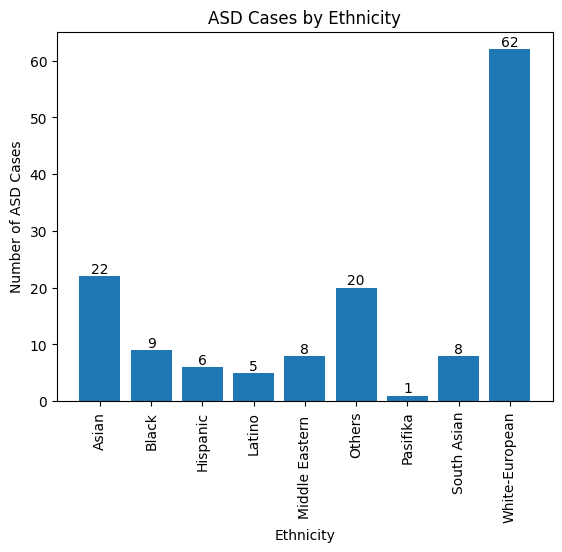

In [29]:
asd_counts_ethnicity = data[data['Class/ASD'] == 'YES'].groupby('ethnicity').size()
bars=plt.bar(asd_counts_ethnicity.index, asd_counts_ethnicity.values)
plt.xlabel('Ethnicity')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Ethnicity')
plt.xticks(rotation=90)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


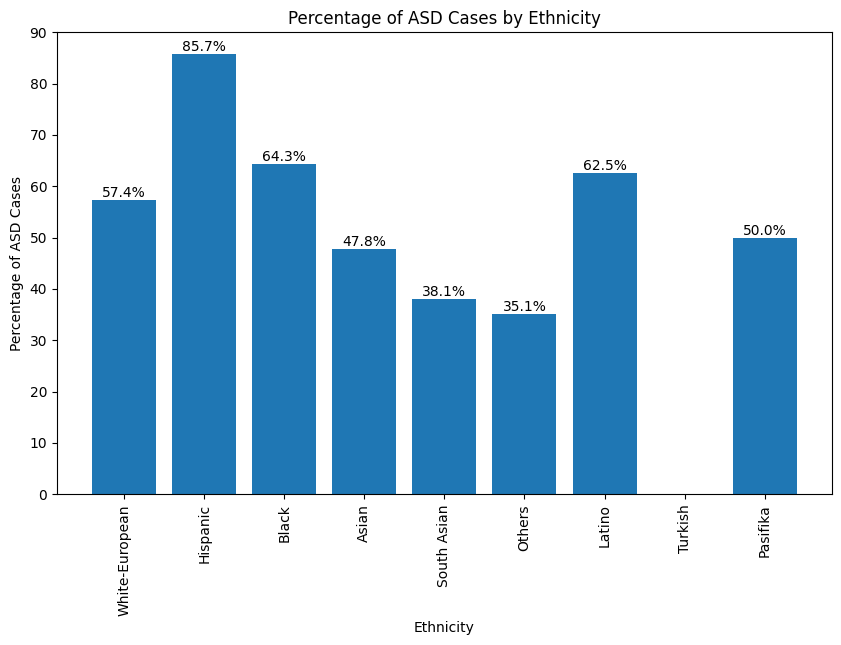

In [30]:
total_ethnicity_counts = data.groupby('ethnicity').size()
asd_counts_ethnicity = data[data['Class/ASD'] == 'YES'].groupby('ethnicity').size()
asd_percentage_ethnicity = (asd_counts_ethnicity / total_ethnicity_counts) * 100
plt.figure(figsize=(10, 6))
bars = plt.bar(asd_percentage_ethnicity.reindex(labels).index, asd_percentage_ethnicity.reindex(labels).values)
plt.xlabel('Ethnicity')
plt.ylabel('Percentage of ASD Cases')
plt.title('Percentage of ASD Cases by Ethnicity')
plt.xticks(rotation=90)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%', va='bottom', ha='center')
plt.show()

In [31]:
data.groupby('gender').size()

gender
f     84
m    208
dtype: int64

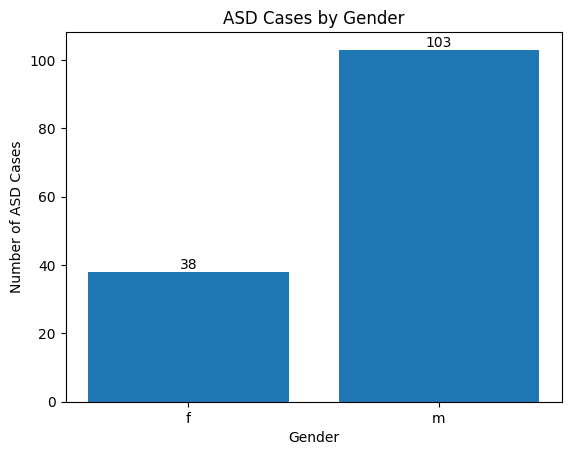

In [32]:
asd_counts_sex = data[data['Class/ASD'] == 'YES'].groupby('gender').size()
bars=plt.bar(asd_counts_sex.index, asd_counts_sex.values)
plt.xlabel('Gender')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Gender')
plt.xticks()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

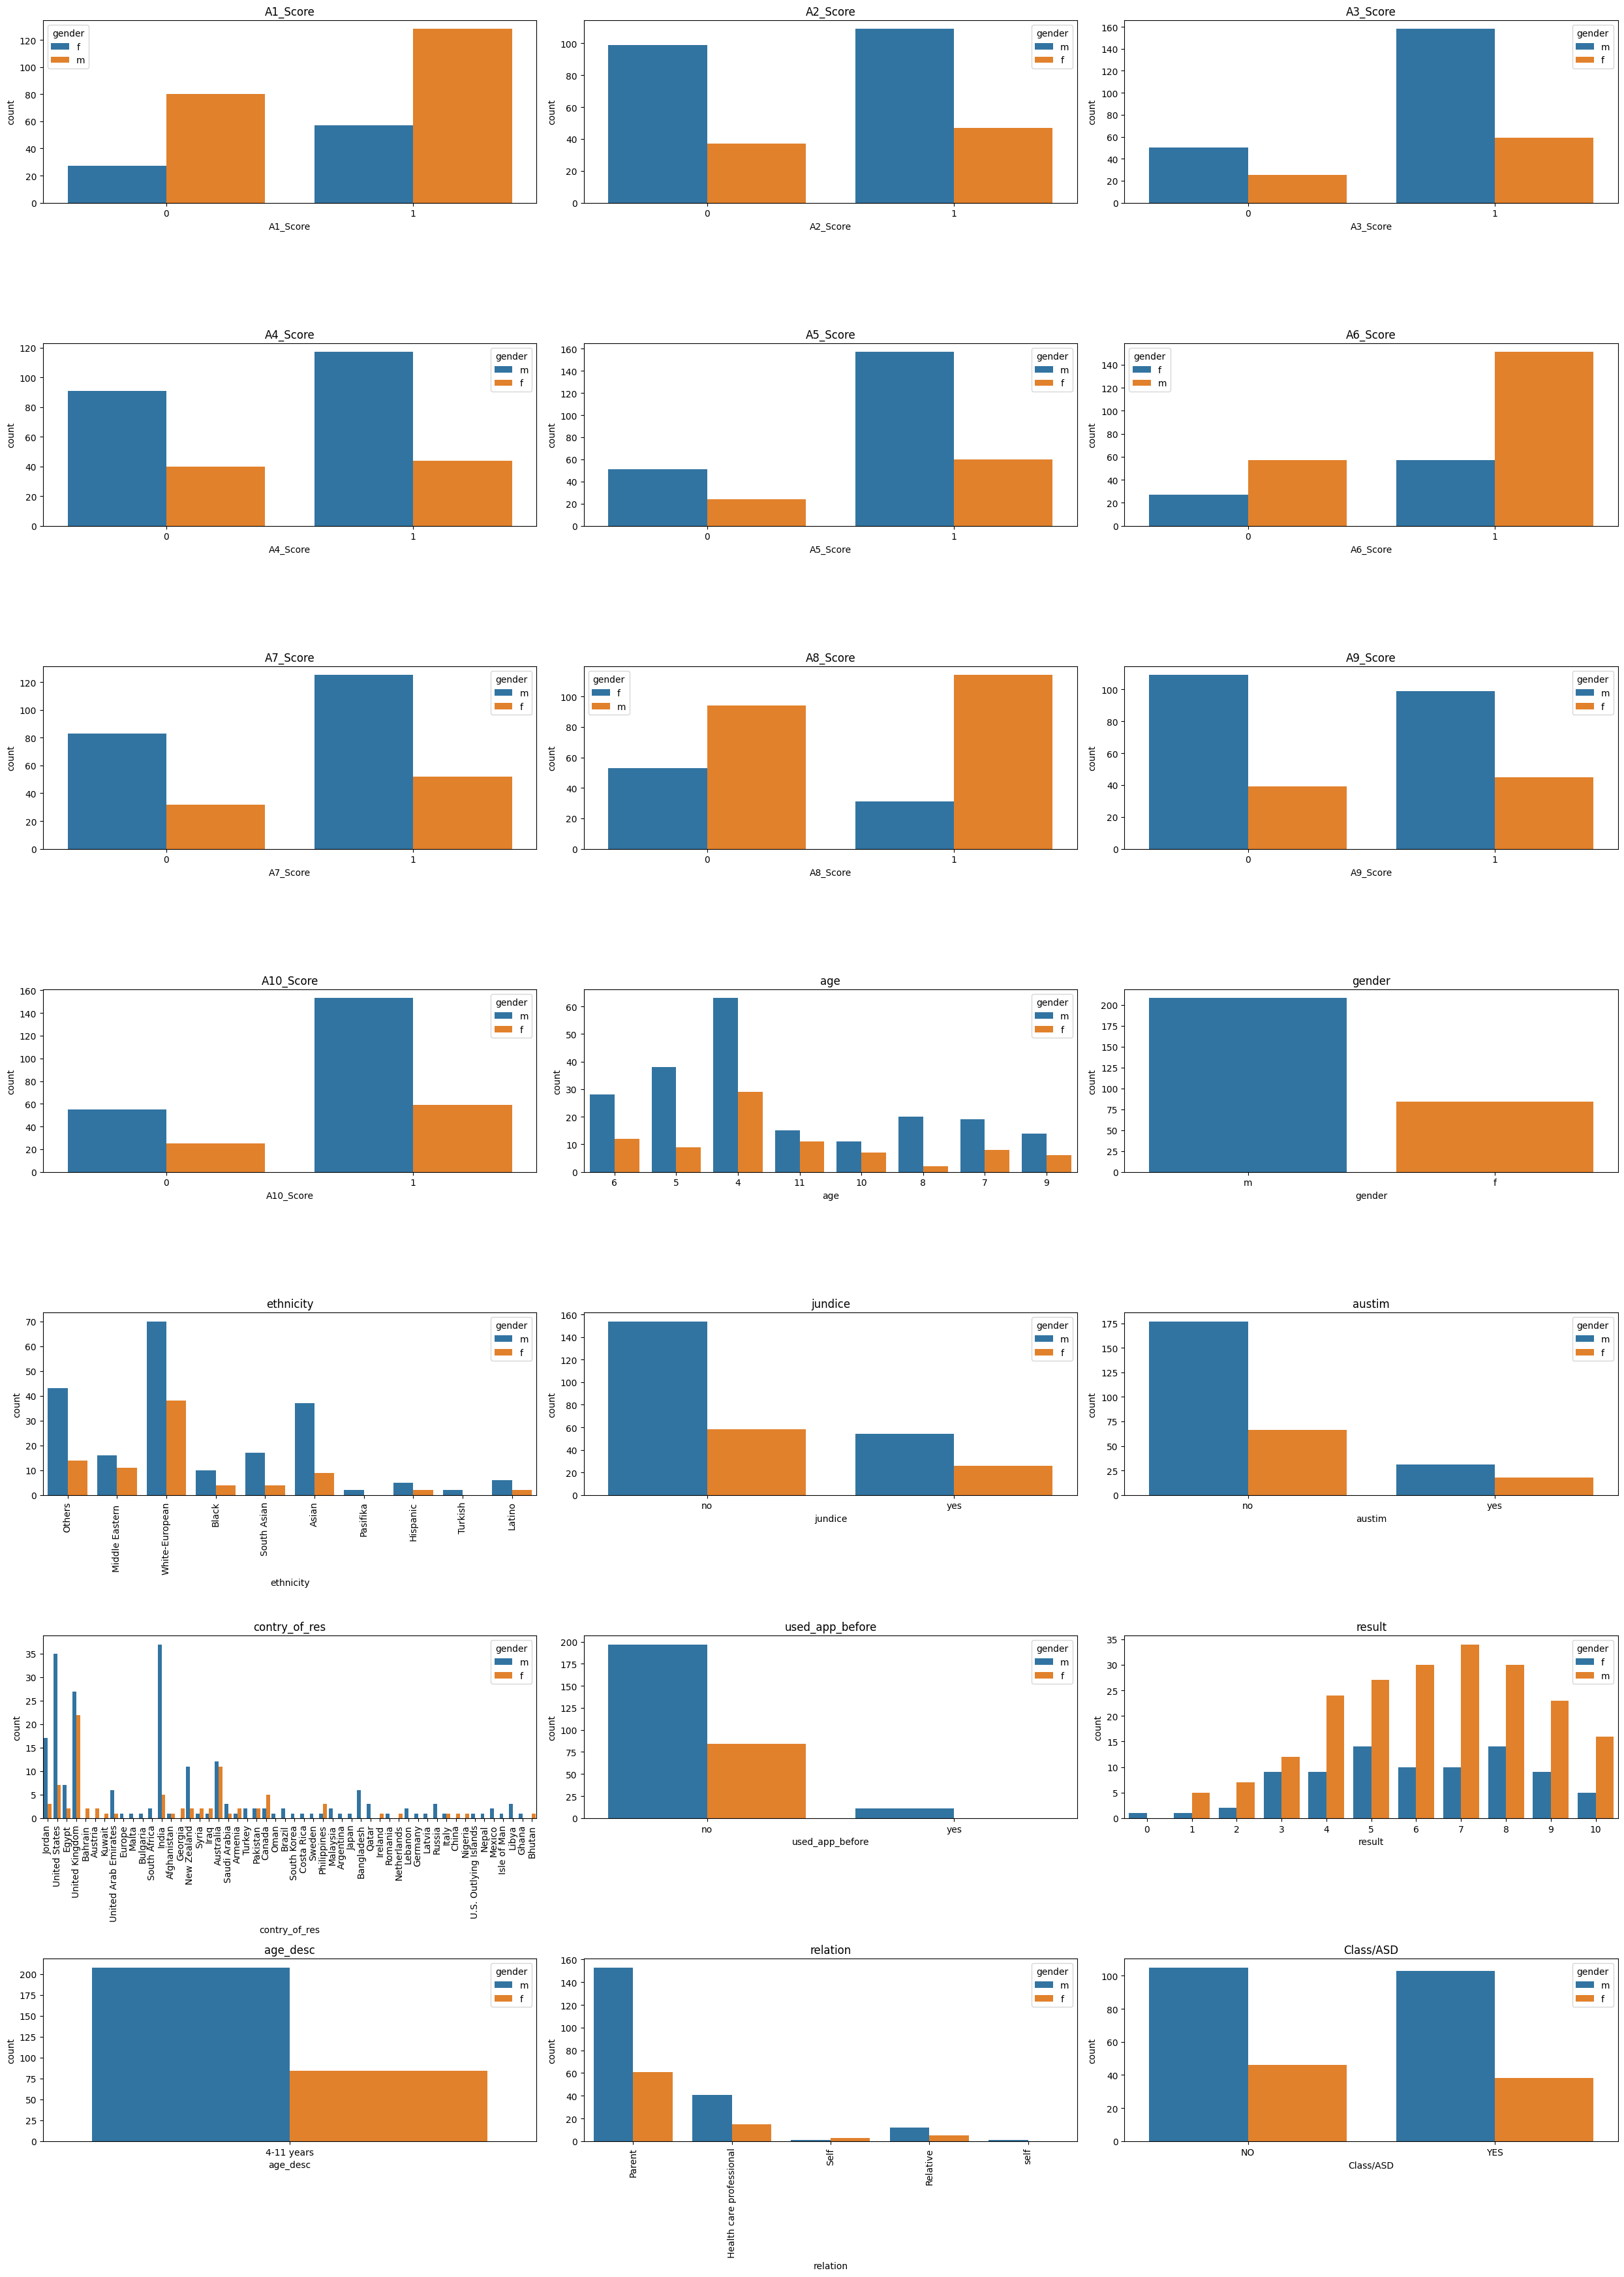

In [33]:
fig, axes = plt.subplots(7, 3, figsize=(25, 35))
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :]):
    sns.countplot(hue=data["gender"], x=data[col], ax=axes[i])
    axes[i].set_title(col)
    if col == "contry_of_res" or col == "ethnicity" or col == "relation":
        axes[i].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

In [34]:
data.groupby('jundice').size()

jundice
no     212
yes     80
dtype: int64

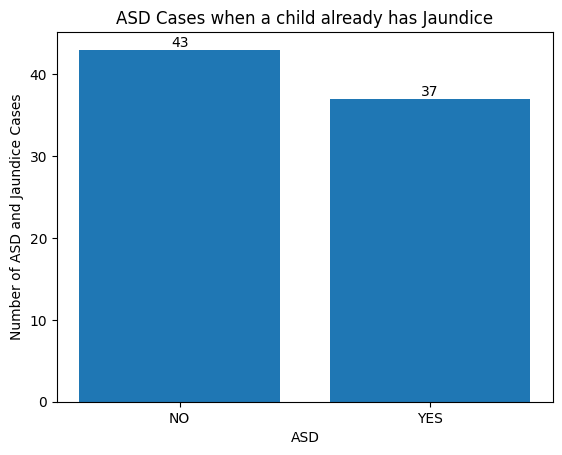

In [35]:
asd_counts_jundice = data[data['jundice'] == 'yes'].groupby('Class/ASD').size()
bars=plt.bar(asd_counts_jundice.index, asd_counts_jundice.values)
plt.xlabel('ASD')
plt.ylabel('Number of ASD and Jaundice Cases')
plt.title('ASD Cases when a child already has Jaundice')
plt.xticks()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

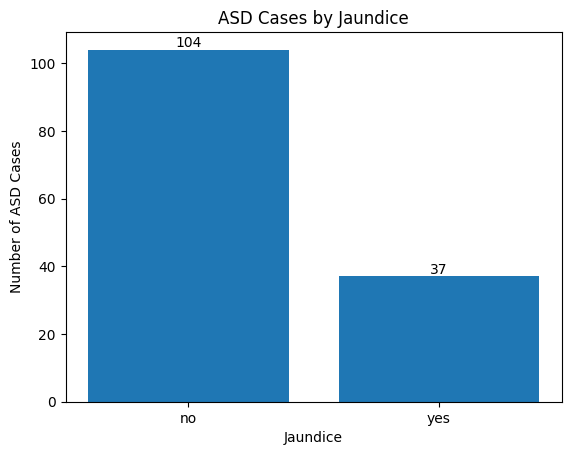

In [36]:
asd_counts_jundice = data[data['Class/ASD'] == 'YES'].groupby('jundice').size()
bars=plt.bar(asd_counts_jundice.index, asd_counts_jundice.values)
plt.xlabel('Jaundice')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Jaundice')
plt.xticks()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

# So we see ASD is not affected by Jaundice for children

In [37]:
data.groupby("austim").size()

austim
no     243
yes     49
dtype: int64

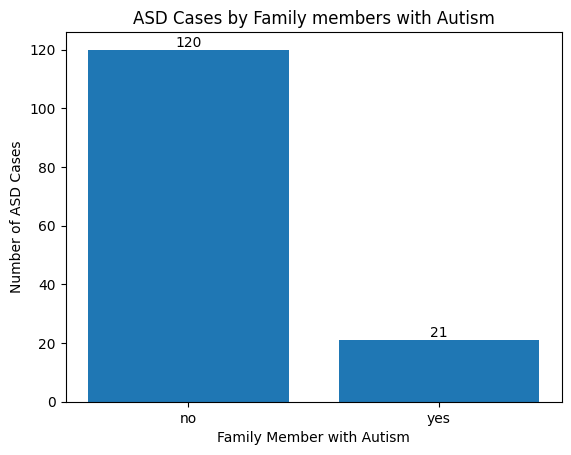

In [38]:
asd_counts = data[data['Class/ASD'] == 'YES'].groupby('austim').size()
bars=plt.bar(asd_counts.index, asd_counts.values)
plt.xlabel('Family Member with Autism')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Family members with Autism')
plt.xticks()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

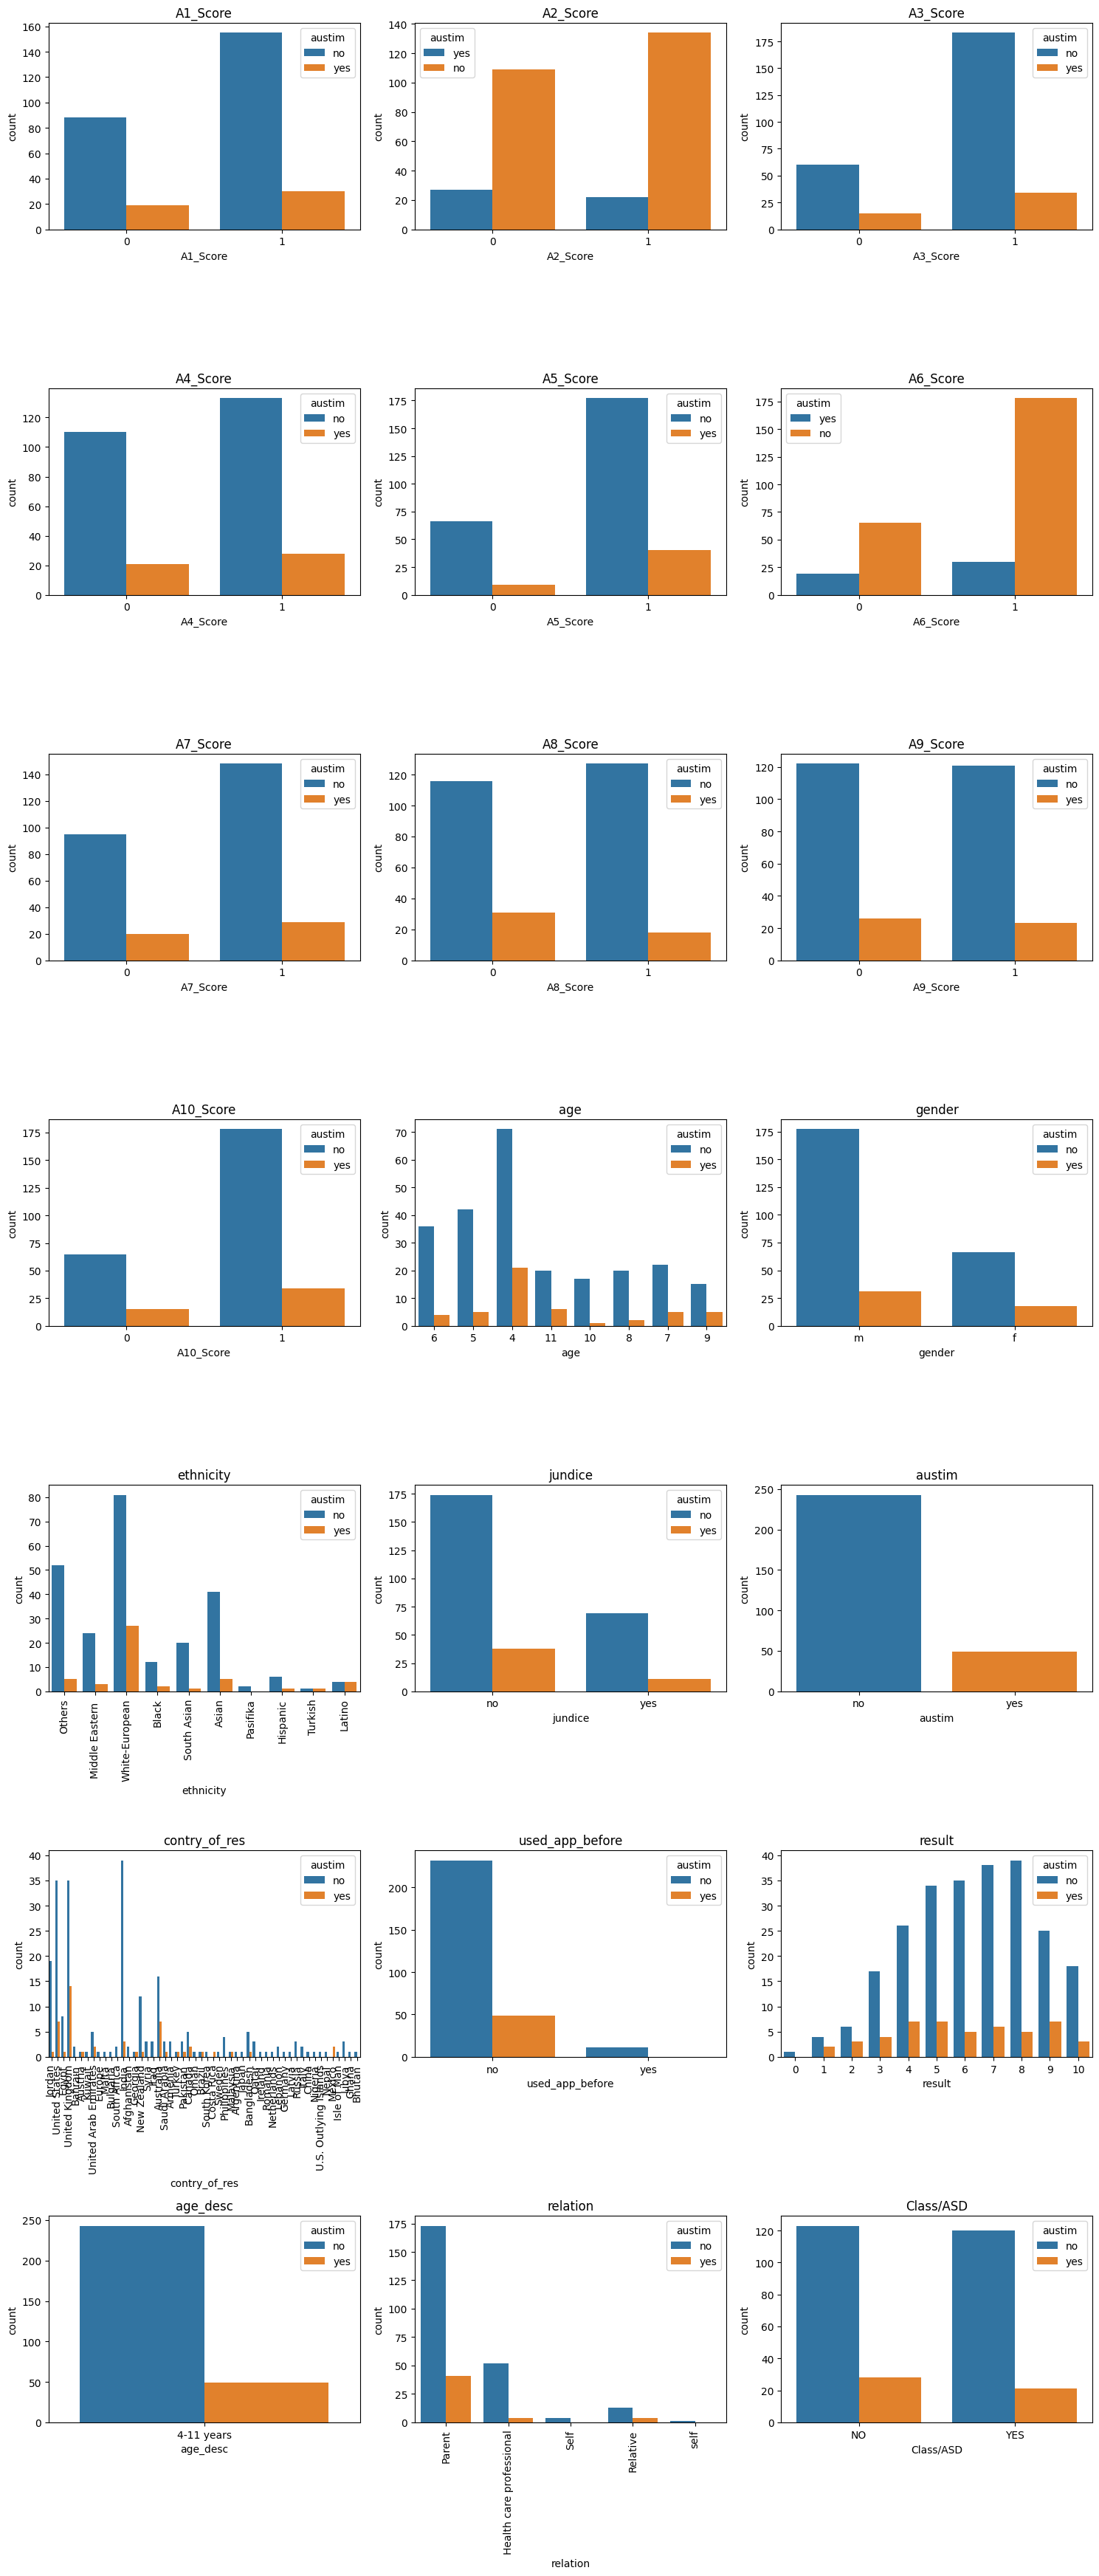

In [39]:
fig, axes = plt.subplots(7, 3, figsize=(15, 35))
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :]):
    sns.countplot(hue=data["austim"], x=data[col], ax=axes[i])
    axes[i].set_title(col)
    if col == "contry_of_res" or col == "ethnicity" or col == "relation":
        axes[i].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

# So if a family member has autism, not necessarily a child will have ASD

In [40]:
data.groupby("relation").size()

relation
Health care professional     56
Parent                      214
Relative                     17
Self                          4
self                          1
dtype: int64

In [41]:
data['relation'].replace('self','Self',inplace=True)

In [42]:
data.groupby("relation").size()


relation
Health care professional     56
Parent                      214
Relative                     17
Self                          5
dtype: int64

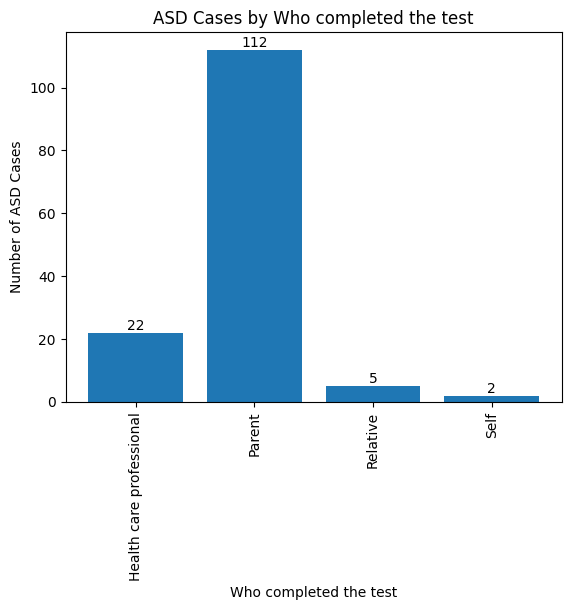

In [43]:
asd_counts = data[data['Class/ASD'] == 'YES'].groupby('relation').size()
bars=plt.bar(asd_counts.index, asd_counts.values)
plt.xlabel('Who completed the test')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Who completed the test')
plt.xticks(rotation=90)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

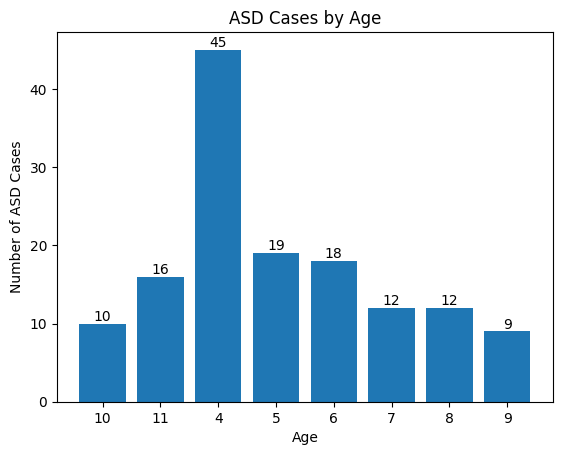

In [44]:
asd_counts = data[data['Class/ASD'] == 'YES'].groupby('age').size()
bars=plt.bar(asd_counts.index, asd_counts.values)
plt.xlabel('Age')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Age')
plt.xticks()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.show()

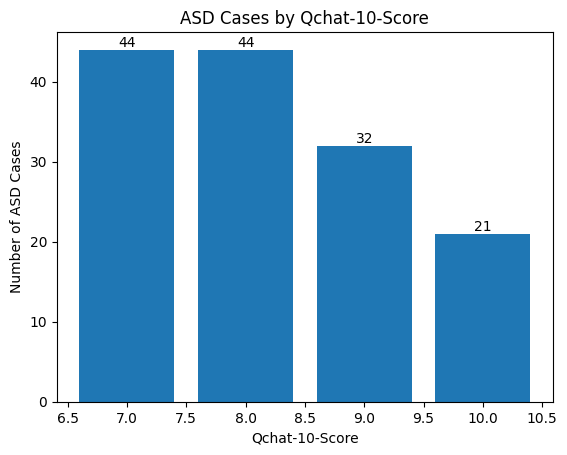

In [45]:
asd_counts = data[data['Class/ASD'] == 'YES'].groupby('result').size()
bars=plt.bar(asd_counts.index, asd_counts.values)
plt.xlabel('Qchat-10-Score')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases by Qchat-10-Score')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.xticks()
plt.show()

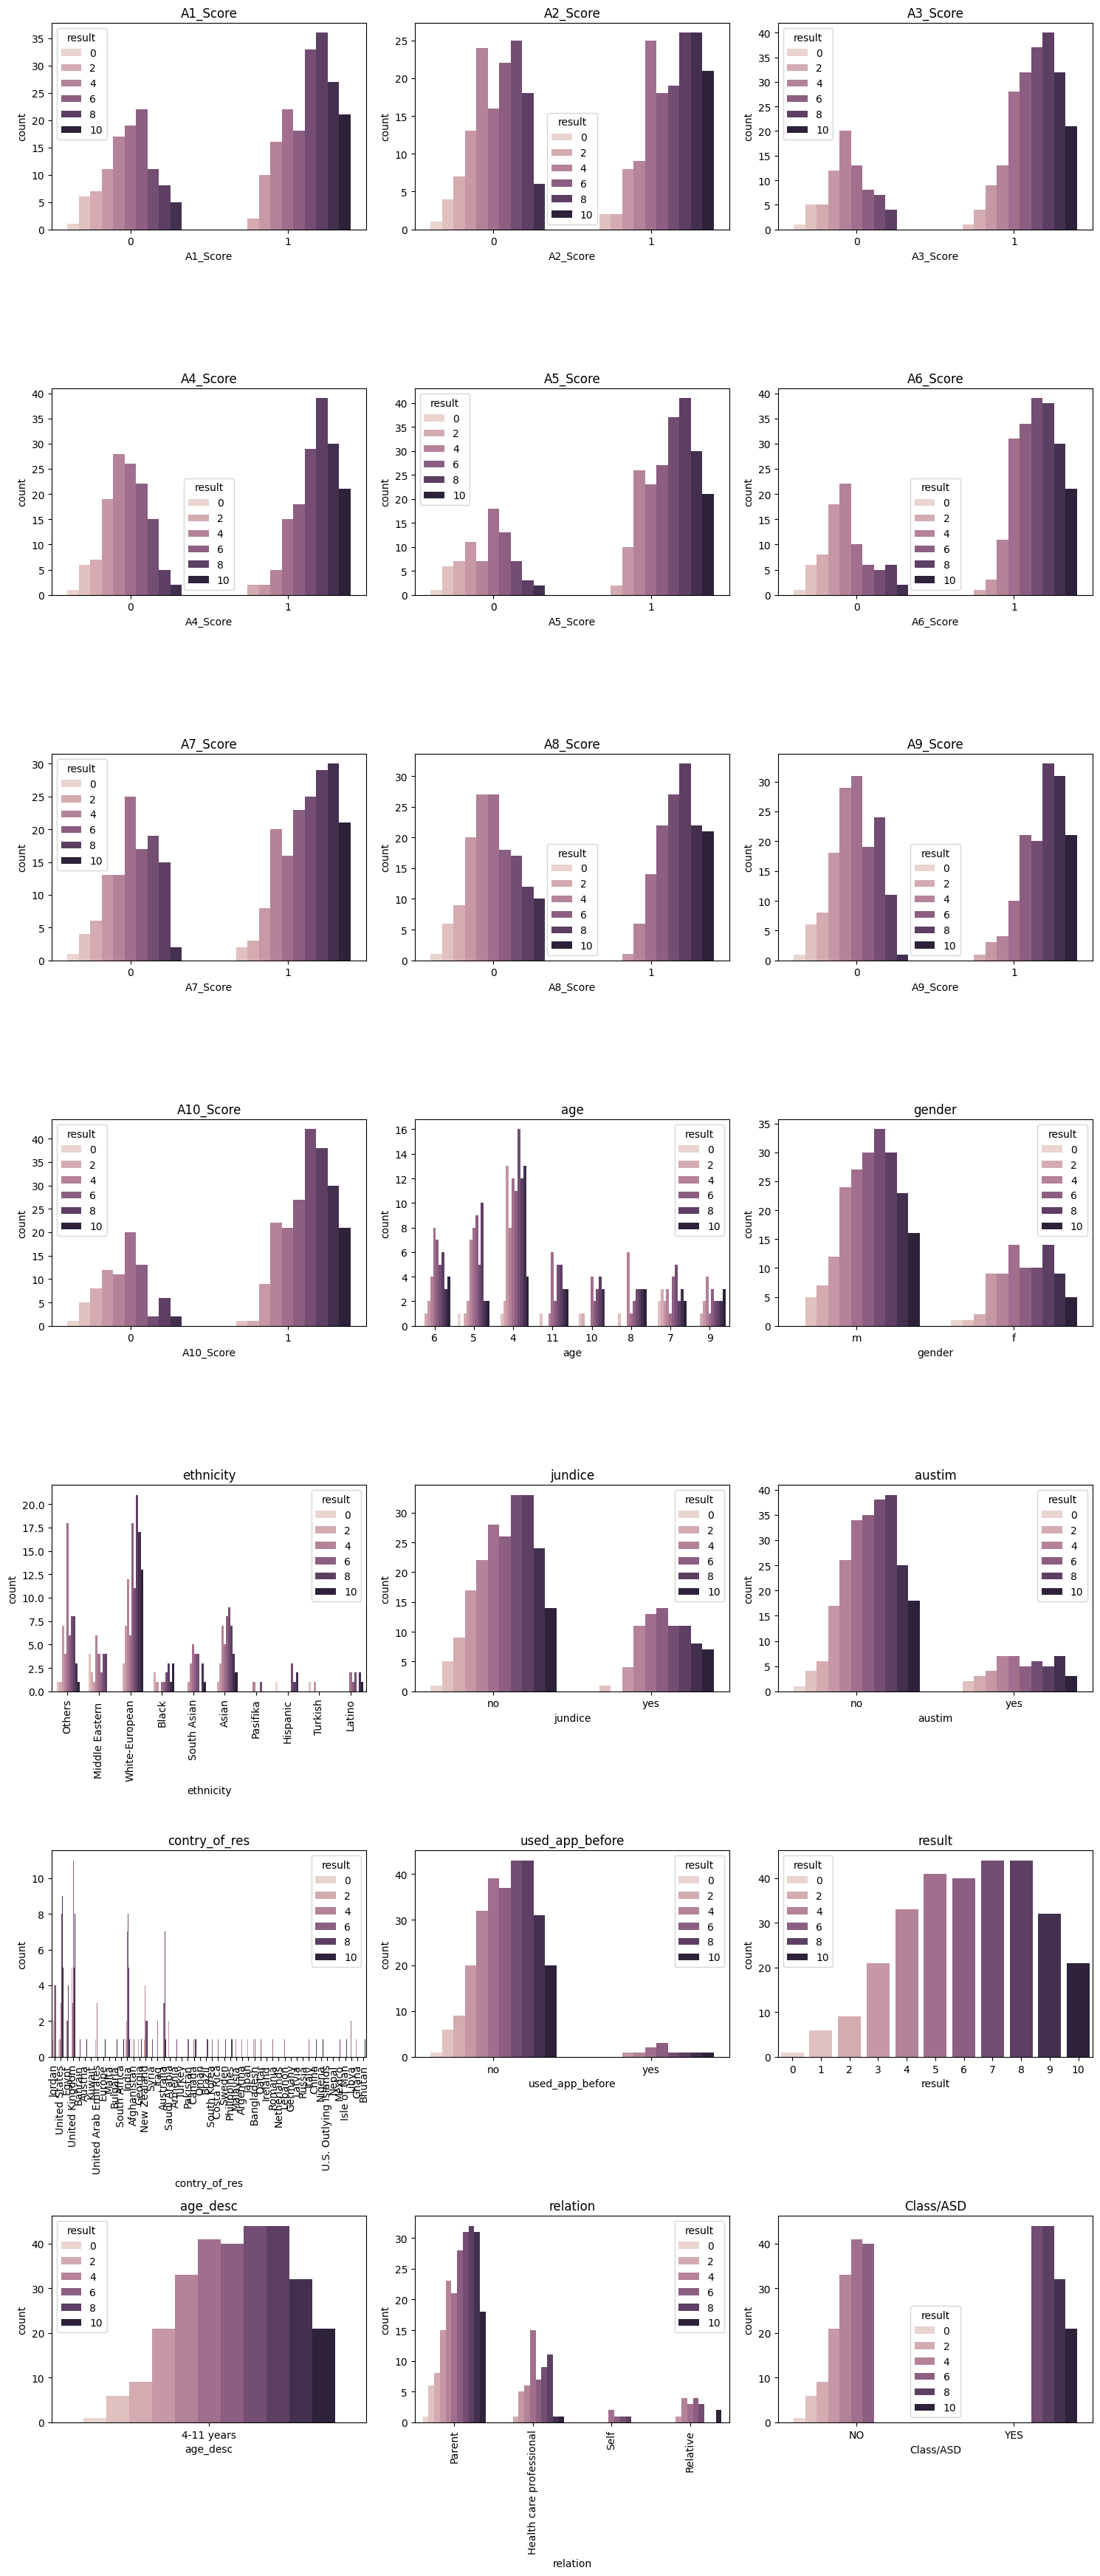

In [46]:
fig, axes = plt.subplots(7, 3, figsize=(15, 35))
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :]):
    sns.countplot(hue=data["result"], x=data[col], ax=axes[i])
    axes[i].set_title(col)
    if col == "contry_of_res" or col == "ethnicity" or col == "relation":
        axes[i].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

In [47]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,Others,no,no,Jordan,yes,5,4-11 years,Health care professional,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,Others,yes,no,Jordan,no,4,4-11 years,Health care professional,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [48]:
pd.set_option('display.max_columns', None)


In [49]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,6,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,6,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,6,m,Others,no,no,Jordan,yes,5,4-11 years,Health care professional,NO
3,0,1,0,0,1,1,0,0,0,1,5,f,Others,yes,no,Jordan,no,4,4-11 years,Health care professional,NO
4,1,1,1,1,1,1,1,1,1,1,5,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [50]:
for i in data.columns:
    print(i)
    print(f"{data[i].unique()}\n")

A1_Score
[1 0]

A2_Score
[1 0]

A3_Score
[0 1]

A4_Score
[0 1]

A5_Score
[1 0]

A6_Score
[1 0]

A7_Score
[0 1]

A8_Score
[1 0]

A9_Score
[0 1]

A10_Score
[0 1]

age
['6' '5' '4' '11' '10' '8' '7' '9']

gender
['m' 'f']

ethnicity
['Others' 'Middle Eastern ' 'White-European' 'Black' 'South Asian' 'Asian'
 'Pasifika' 'Hispanic' 'Turkish' 'Latino']

jundice
['no' 'yes']

austim
['no' 'yes']

contry_of_res
['Jordan' 'United States' 'Egypt' 'United Kingdom' 'Bahrain' 'Austria'
 'Kuwait' 'United Arab Emirates' 'Europe' 'Malta' 'Bulgaria'
 'South Africa' 'India' 'Afghanistan' 'Georgia' 'New Zealand' 'Syria'
 'Iraq' 'Australia' 'Saudi Arabia' 'Armenia' 'Turkey' 'Pakistan' 'Canada'
 'Oman' 'Brazil' 'South Korea' 'Costa Rica' 'Sweden' 'Philippines'
 'Malaysia' 'Argentina' 'Japan' 'Bangladesh' 'Qatar' 'Ireland' 'Romania'
 'Netherlands' 'Lebanon' 'Germany' 'Latvia' 'Russia' 'Italy' 'China'
 'Nigeria' 'U.S. Outlying Islands' 'Nepal' 'Mexico' 'Isle of Man' 'Libya'
 'Ghana' 'Bhutan']

used_app_before

In [51]:
data.rename(columns={'gender': 'Gender'}, inplace=True)

In [52]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,Gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,6,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,6,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,6,m,Others,no,no,Jordan,yes,5,4-11 years,Health care professional,NO
3,0,1,0,0,1,1,0,0,0,1,5,f,Others,yes,no,Jordan,no,4,4-11 years,Health care professional,NO
4,1,1,1,1,1,1,1,1,1,1,5,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [53]:
data.rename(columns={'Gender': 'gender'}, inplace=True)


In [54]:
replacements = {
    'f': 'F',
    'm': 'M',
}
data['gender'] = data['gender'].replace(replacements)
replacements = {
    'yes': 'Yes',
    'no': 'No',
}
data['jundice'] = data['jundice'].replace(replacements)
replacements = {
    'yes': 'Yes',
    'no': 'No',
}
data['austim'] = data['austim'].replace(replacements)

replacements = {
    'yes': 'Yes',
    'no': 'No',
}
data['used_app_before'] = data['used_app_before'].replace(replacements)
replacements = {
    'YES': 'Yes',
    'NO': 'No',
}
data['Class/ASD'] = data['Class/ASD'].replace(replacements)

In [55]:
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,6,M,Others,No,No,Jordan,No,5,4-11 years,Parent,No
1,1,1,0,0,1,1,0,1,0,0,6,M,Middle Eastern,No,No,Jordan,No,5,4-11 years,Parent,No
2,1,1,0,0,0,1,1,1,0,0,6,M,Others,No,No,Jordan,Yes,5,4-11 years,Health care professional,No
3,0,1,0,0,1,1,0,0,0,1,5,F,Others,Yes,No,Jordan,No,4,4-11 years,Health care professional,No
4,1,1,1,1,1,1,1,1,1,1,5,M,Others,Yes,No,United States,No,10,4-11 years,Parent,Yes


# Creating two dataframes x and y where x is without the final result and y contains all the columns to train


In [56]:
x = data.drop("Class/ASD",axis=1)
y = data["Class/ASD"]

In [57]:
data.drop(columns=['age_desc'], inplace=True)

In [58]:
x = data.drop("Class/ASD",axis=1)
y = data["Class/ASD"]

In [59]:
for i in data.columns:
    print(i)
    print(f"{data[i].unique()}\n")

A1_Score
[1 0]

A2_Score
[1 0]

A3_Score
[0 1]

A4_Score
[0 1]

A5_Score
[1 0]

A6_Score
[1 0]

A7_Score
[0 1]

A8_Score
[1 0]

A9_Score
[0 1]

A10_Score
[0 1]

age
['6' '5' '4' '11' '10' '8' '7' '9']

gender
['M' 'F']

ethnicity
['Others' 'Middle Eastern ' 'White-European' 'Black' 'South Asian' 'Asian'
 'Pasifika' 'Hispanic' 'Turkish' 'Latino']

jundice
['No' 'Yes']

austim
['No' 'Yes']

contry_of_res
['Jordan' 'United States' 'Egypt' 'United Kingdom' 'Bahrain' 'Austria'
 'Kuwait' 'United Arab Emirates' 'Europe' 'Malta' 'Bulgaria'
 'South Africa' 'India' 'Afghanistan' 'Georgia' 'New Zealand' 'Syria'
 'Iraq' 'Australia' 'Saudi Arabia' 'Armenia' 'Turkey' 'Pakistan' 'Canada'
 'Oman' 'Brazil' 'South Korea' 'Costa Rica' 'Sweden' 'Philippines'
 'Malaysia' 'Argentina' 'Japan' 'Bangladesh' 'Qatar' 'Ireland' 'Romania'
 'Netherlands' 'Lebanon' 'Germany' 'Latvia' 'Russia' 'Italy' 'China'
 'Nigeria' 'U.S. Outlying Islands' 'Nepal' 'Mexico' 'Isle of Man' 'Libya'
 'Ghana' 'Bhutan']

used_app_before

## Now we will do One Hot Encoding for the categorical variables (ethnicity, contry_of_res, relation) of the dataframe x

In [60]:
x=pd.get_dummies(x,columns=["ethnicity", "relation" , "contry_of_res"], drop_first=True)

## We will do Label Encoding to convert categorical values into numerical values

In [61]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
x['gender']=le.fit_transform(x['gender'])
x['jundice']=le.fit_transform(x['jundice'])
x['austim']=le.fit_transform(x['austim'])
x['used_app_before']=le.fit_transform(x['used_app_before'])

## Now we will split the dataset into train and test sets

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=69)

## We will scale the features by Feature Scaling

In [114]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [115]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
def train_model(model, x_train, y_train, x_test, y_test):
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    matrix=confusion_matrix(y_test,y_pred)
    print("Confusion Matrix is: ")
    print(matrix)
    print("\n\nScore Table is: ")
    score_df = pd.DataFrame([[accuracy, precision, recall, f1]], 
                            columns=["accuracy", "precision", "recall", "f1"])
    
    return score_df

## Logistic Regression

In [116]:

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
result=train_model(model,x_train_scaled, y_train, x_test_scaled, y_test)
result.index=["Logistic Regression"]
result

Confusion Matrix is: 
[[27  1]
 [ 3 28]]


Score Table is: 


,accuracy,precision,recall,f1
Logistic Regression,0.932203,0.965517,0.903226,0.933333


## Decision Tree Classifier

In [118]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier()
dt = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
dt.index = ["Decision Tree Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, dt], ignore_index=False)

print(result)

Confusion Matrix is: 
[[28  0]
 [ 0 31]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier  1.000000   1.000000  1.000000  1.000000


In [119]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
rfc = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
rfc.index = ["Random Forest Classifier"]
if 'result' not in locals() or not isinstance(result, pd.DataFrame):

    result = pd.DataFrame()

result = pd.concat([result, rfc], ignore_index=False)

print(result)

Confusion Matrix is: 
[[28  0]
 [ 0 31]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier  1.000000   1.000000  1.000000  1.000000
Random Forest Classifier  1.000000   1.000000  1.000000  1.000000


In [120]:
from xgboost import XGBClassifier

model = XGBClassifier()
xg = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
xg.index = ["XGBoost Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, xg], ignore_index=False)

print(result)

Confusion Matrix is: 
[[28  0]
 [ 0 31]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier  1.000000   1.000000  1.000000  1.000000
Random Forest Classifier  1.000000   1.000000  1.000000  1.000000
XGBoost Classifier        1.000000   1.000000  1.000000  1.000000


In [121]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
gb = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
gb.index = ["Gradient Boosting Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, gb], ignore_index=False)

print(result)


Confusion Matrix is: 
[[28  0]
 [ 0 31]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier      1.000000   1.000000  1.000000  1.000000
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000


In [122]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier()
adb = train_model(model, x_train_scaled, y_train,x_test_scaled, y_test)
adb.index = ["AdaBoost Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, adb], ignore_index=False)

print(result)


Confusion Matrix is: 
[[28  0]
 [ 0 31]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier      1.000000   1.000000  1.000000  1.000000
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000
AdaBoost Classifier           1.000000   1.000000  1.000000  1.000000


In [123]:
from sklearn.svm import SVC

model = SVC()
svm = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
svm.index = ["SVM Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, svm], ignore_index=False)

print(result)


Confusion Matrix is: 
[[25  3]
 [ 4 27]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.932203   0.965517  0.903226  0.933333
Decision Tree Classifier      1.000000   1.000000  1.000000  1.000000
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000
AdaBoost Classifier           1.000000   1.000000  1.000000  1.000000
SVM Classifier                0.881356   0.900000  0.870968  0.885246
